# 🛡️ Detecção de Fraudes em Transações Financeiras

## Análise Exploratória dos Dados (EDA)

**Autor:** Lucas Frota

### Objetivos

- Compreender o conjunto de dados
- Avaliar o desbalanceamento das classes
- Identificar possíveis problemas nos dados
- Explorar as principais características antes da modelagem

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
DATA_URL = (
    "https://storage.googleapis.com/"
    "download.tensorflow.org/data/creditcard.csv"
)

df = pd.read_csv(DATA_URL)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
print("=" * 60)
print("INFORMAÇÕES GERAIS")
print("=" * 60)

print(f"Linhas : {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

INFORMAÇÕES GERAIS
Linhas : 284807
Colunas: 31


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
print(f"Valores nulos: {df.isnull().sum().sum()}")

Valores nulos: 0


In [8]:
duplicatas = df.duplicated().sum()

print(f"Duplicatas: {duplicatas}")

Duplicatas: 1081


In [9]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
df["Class"].value_counts(normalize=True) * 100

Class
0   99.8273
1    0.1727
Name: proportion, dtype: float64

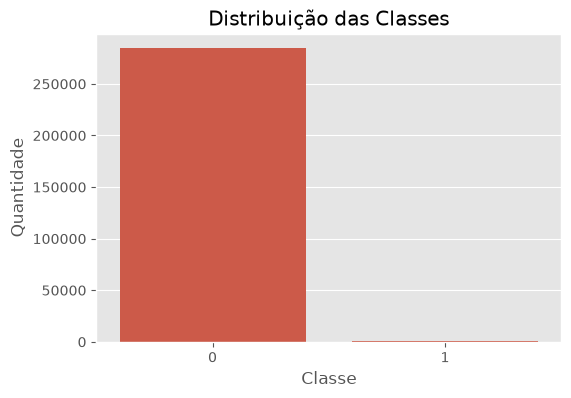

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

## Conclusão

O conjunto de dados apresenta um forte desbalanceamento entre as classes.

Mais de 99% das transações são legítimas e menos de 1% correspondem a fraudes.

Esse comportamento torna a acurácia uma métrica insuficiente para avaliar modelos de classificação.

Durante a modelagem, serão priorizadas métricas como Recall, Precision, F1-score e PR-AUC.

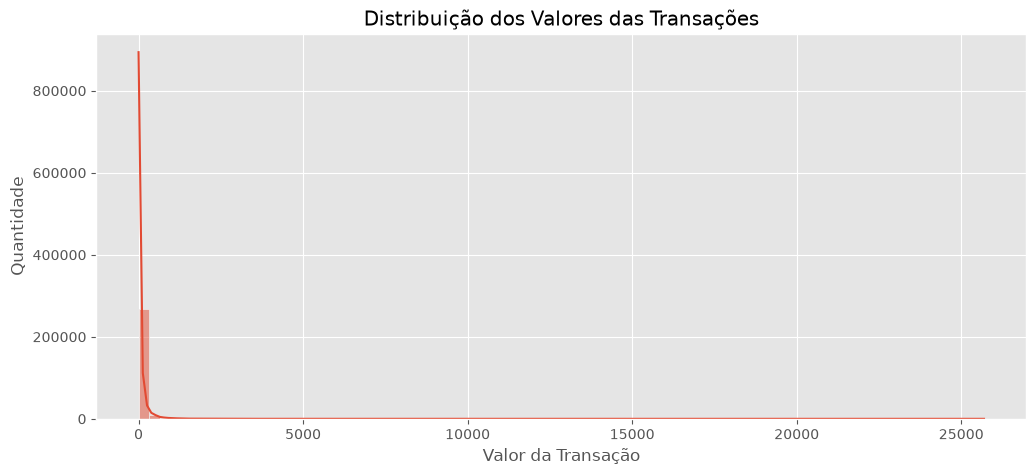

In [12]:
plt.figure(figsize=(12,5))

sns.histplot(
    data=df,
    x="Amount",
    bins=80,
    kde=True
)

plt.title("Distribuição dos Valores das Transações")
plt.xlabel("Valor da Transação")
plt.ylabel("Quantidade")

plt.show()

In [13]:
df["Amount"].describe()


count   284807.0000
mean        88.3496
std        250.1201
min          0.0000
25%          5.6000
50%         22.0000
75%         77.1650
max      25691.1600
Name: Amount, dtype: float64

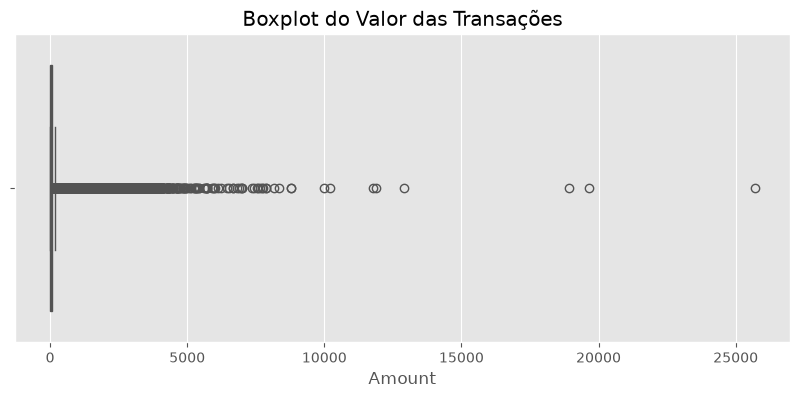

In [14]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["Amount"]
)

plt.title("Boxplot do Valor das Transações")

plt.show()

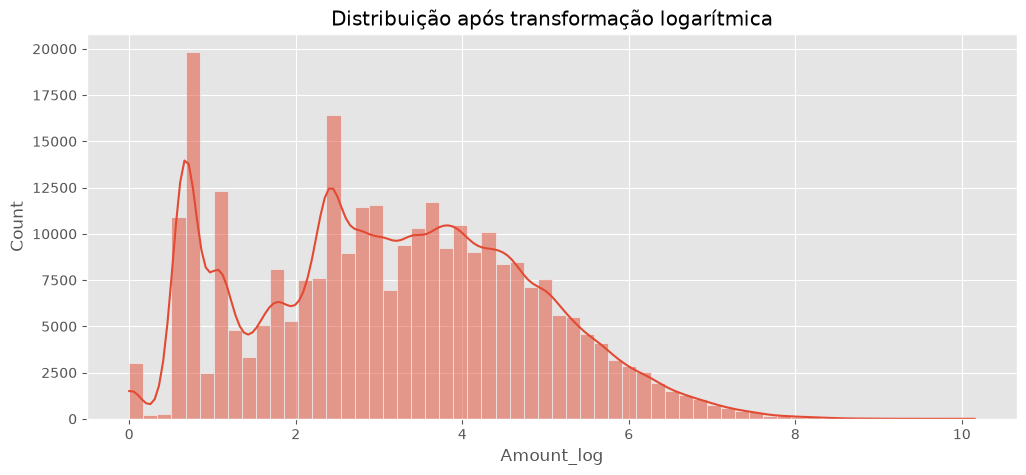

In [15]:
df["Amount_log"] = np.log1p(df["Amount"])

plt.figure(figsize=(12,5))

sns.histplot(
    df["Amount_log"],
    bins=60,
    kde=True
)

plt.title("Distribuição após transformação logarítmica")

plt.show()

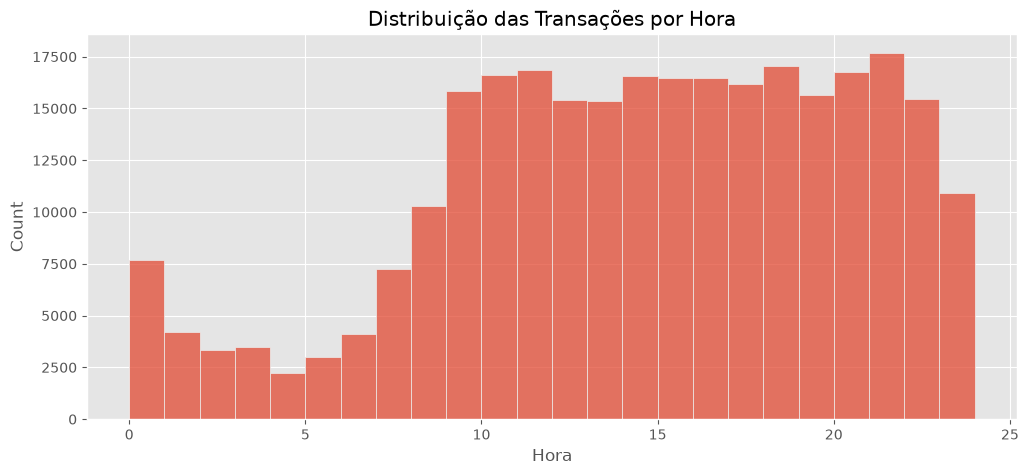

In [16]:
df["Hour"] = (df["Time"] / 3600) % 24


plt.figure(figsize=(12,5))

sns.histplot(
    df["Hour"],
    bins=24
)

plt.title("Distribuição das Transações por Hora")

plt.xlabel("Hora")

plt.show()

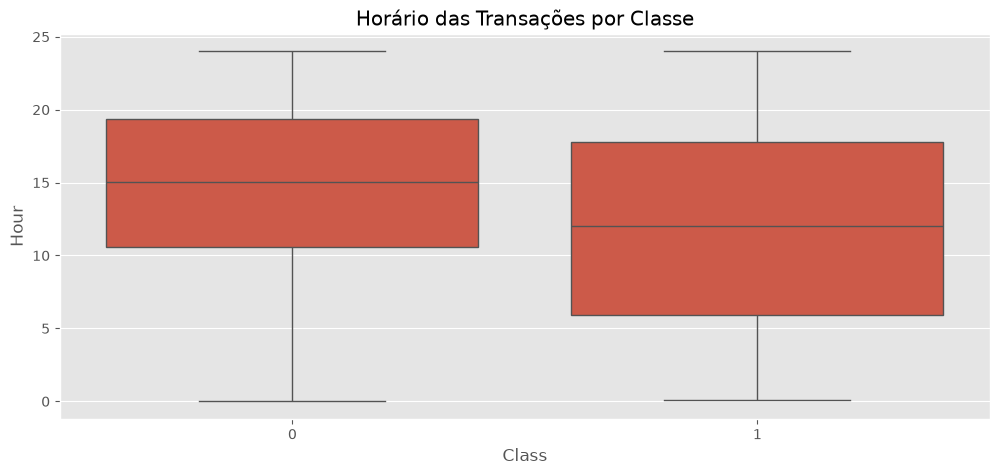

In [17]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Hour"
)

plt.title("Horário das Transações por Classe")

plt.show()

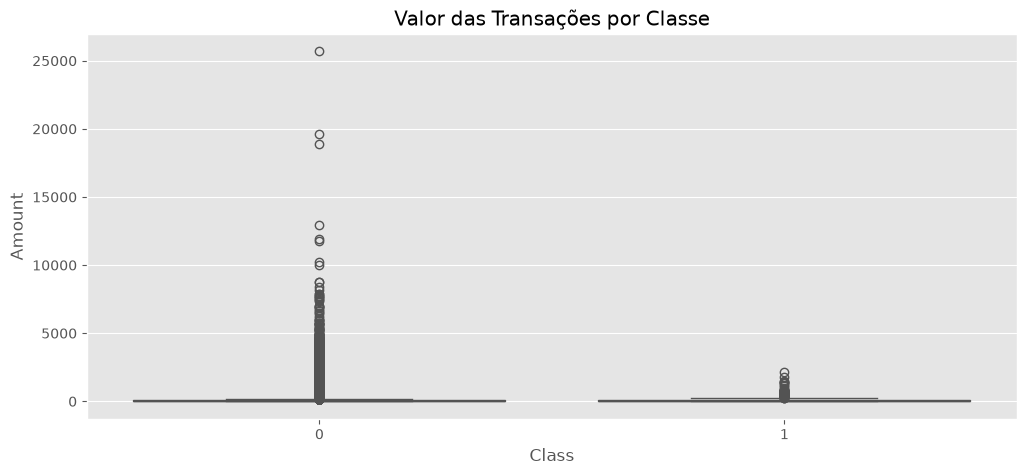

In [18]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Valor das Transações por Classe")

plt.show()

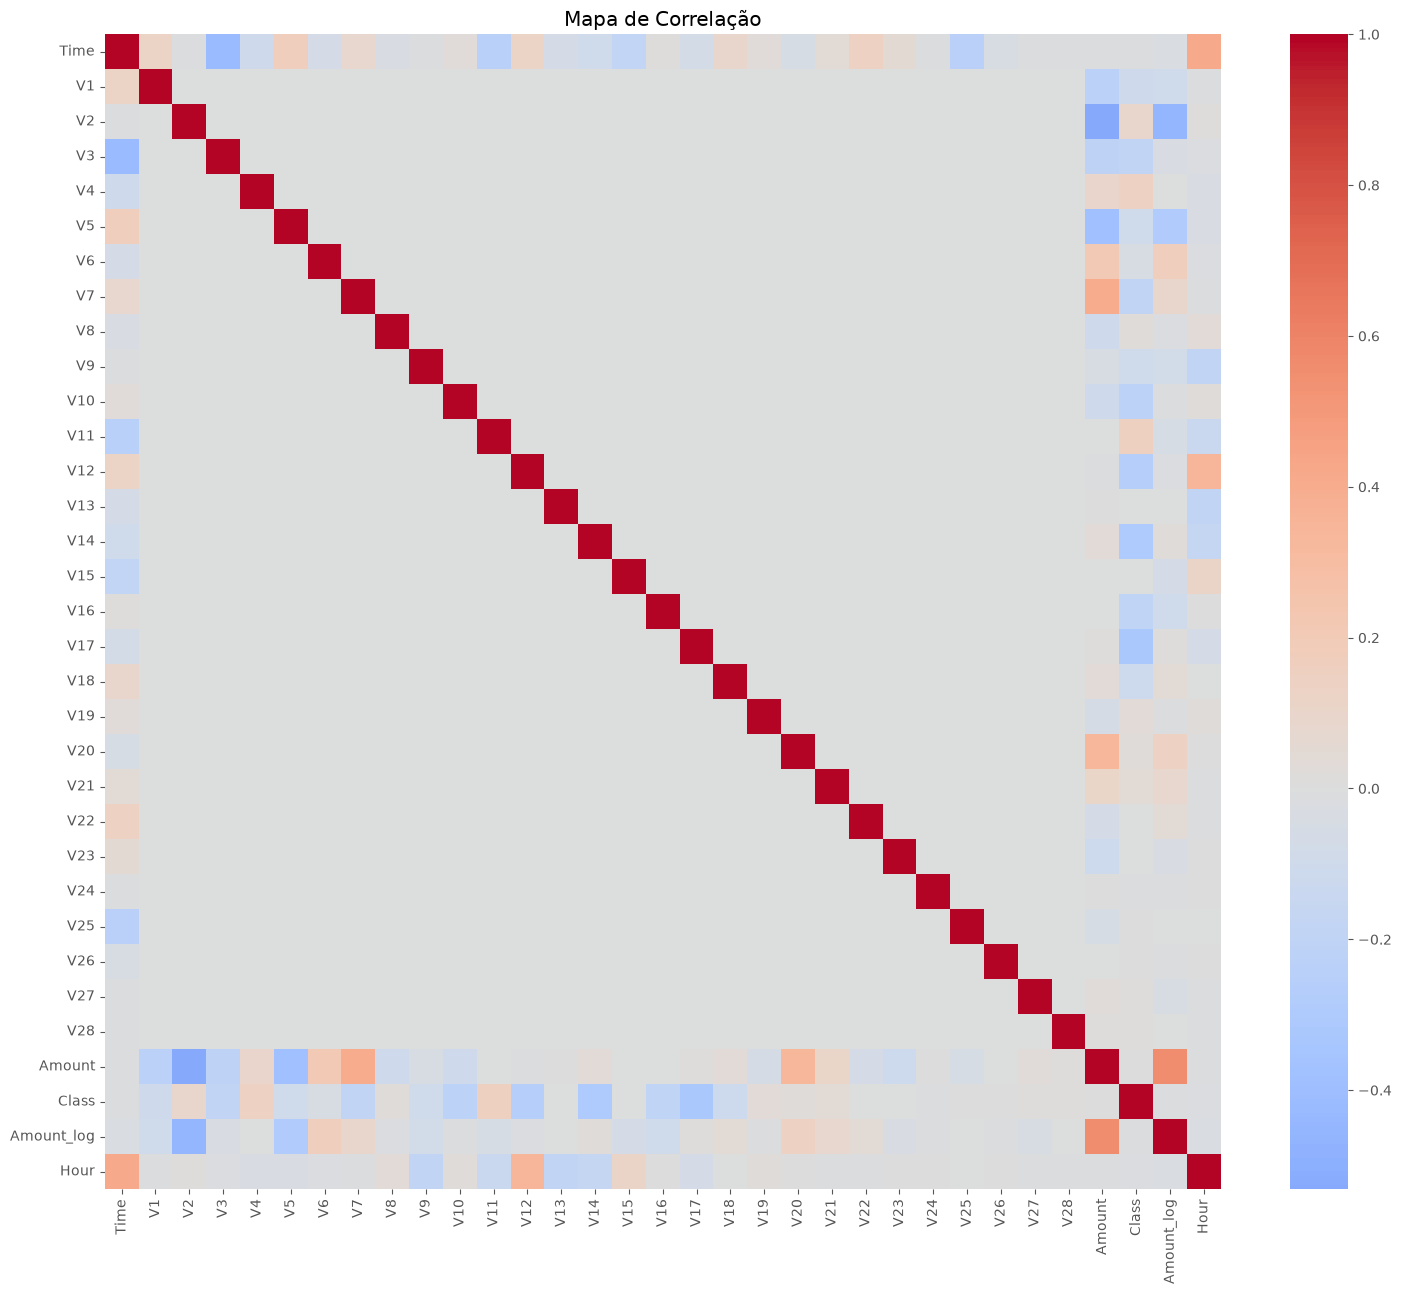

In [19]:
corr = df.corr(numeric_only=True)


plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Mapa de Correlação")

plt.show()

In [20]:
correlation = (
    corr["Class"]
    .sort_values(ascending=False)
)

correlation

Class         1.0000
V11           0.1549
V4            0.1334
V2            0.0913
V21           0.0404
V19           0.0348
V20           0.0201
V8            0.0199
V27           0.0176
V28           0.0095
Amount        0.0056
V26           0.0045
V25           0.0033
V22           0.0008
V23          -0.0027
V15          -0.0042
V13          -0.0046
V24          -0.0072
Amount_log   -0.0083
Time         -0.0123
Hour         -0.0171
V6           -0.0436
V5           -0.0950
V9           -0.0977
V1           -0.1013
V18          -0.1115
V7           -0.1873
V3           -0.1930
V16          -0.1965
V10          -0.2169
V12          -0.2606
V14          -0.3025
V17          -0.3265
Name: Class, dtype: float64

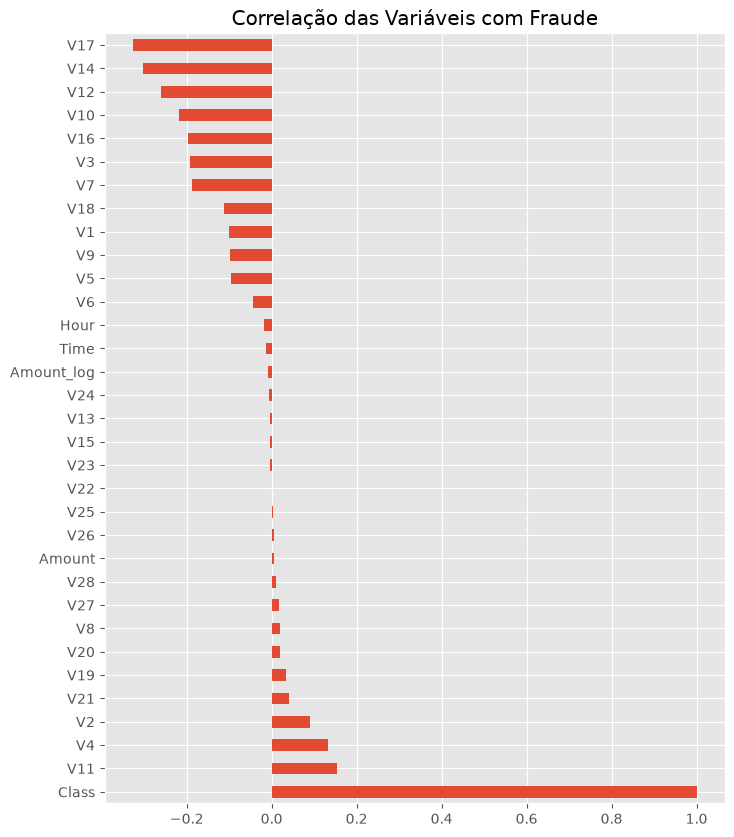

In [21]:
plt.figure(figsize=(8,10))

correlation.plot(kind="barh")

plt.title("Correlação das Variáveis com Fraude")

plt.show()

## Principais descobertas

Durante a análise exploratória foi possível identificar que:

- O conjunto apresenta forte desbalanceamento entre as classes.
- Não foram encontrados valores nulos.
- Existem valores extremos na variável `Amount`.
- A transformação logarítmica reduz a assimetria da distribuição.
- Algumas variáveis apresentam maior correlação com a classe de fraude.
- Essas informações serão utilizadas para orientar a etapa de modelagem.

# Preparação dos Dados

In [22]:
df_model = df.copy()

print(df_model.shape)

(284807, 33)


In [23]:
df_model = df_model.drop(columns=["Time"])

df_model.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Hour
0,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0,5.0148,0.0000
1,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0,1.3056,0.0000
2,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0,5.9393,0.0003
3,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0,4.8243,0.0003
4,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0,4.2625,0.0006


In [24]:
df_model["Amount_log"] = np.log1p(df_model["Amount"])

In [25]:
df_model = df_model.drop(columns=["Amount"])

In [26]:
df_model.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_log',
       'Hour'],
      dtype='str')

In [27]:
X = df_model.drop("Class", axis=1)

y = df_model["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [29]:
print("Treino")

print(X_train.shape)

print(y_train.value_counts())

print()

print("Teste")

print(X_test.shape)

print(y_test.value_counts())

Treino
(199364, 30)
Class
0    199020
1       344
Name: count, dtype: int64

Teste
(85443, 30)
Class
0    85295
1      148
Name: count, dtype: int64


In [30]:
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [31]:
pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['V1','V2','V3',...,'V28','Amount_log','Hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [32]:
y_pred = pipeline.predict(X_test)

y_probs = pipeline.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[83345,  1950],
       [   18,   130]])

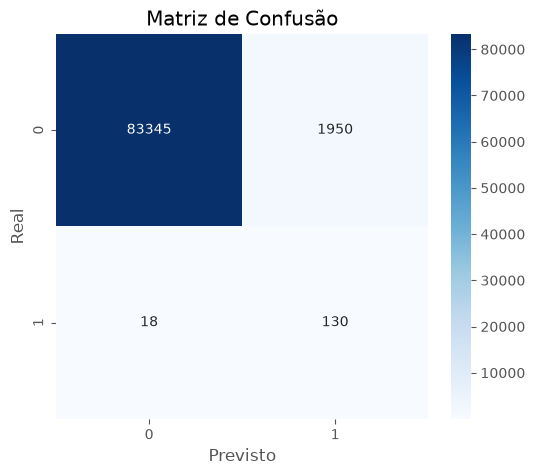

In [35]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Previsto")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

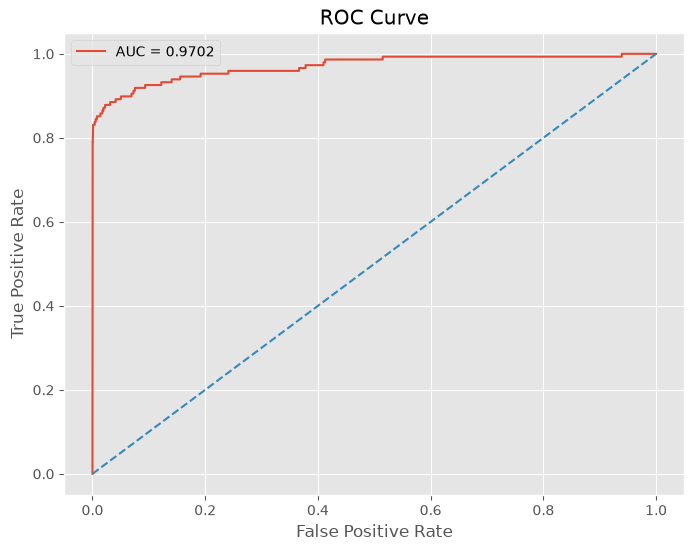

In [36]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_probs):.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [37]:
auc = roc_auc_score(
    y_test,
    y_probs
)

print(f"AUC: {auc:.4f}")

AUC: 0.9702


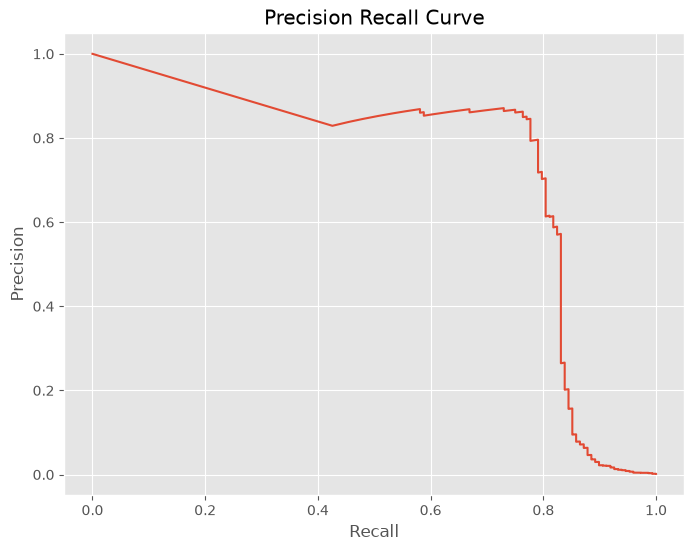

In [38]:
from sklearn.metrics import precision_recall_curve


precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score


metricas = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Valor":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_probs)
    ]

})

metricas

,Métrica,Valor
0,Accuracy,0.9770
1,Precision,0.0625
2,Recall,0.8784
3,F1-score,0.1167
4,ROC-AUC,0.9702


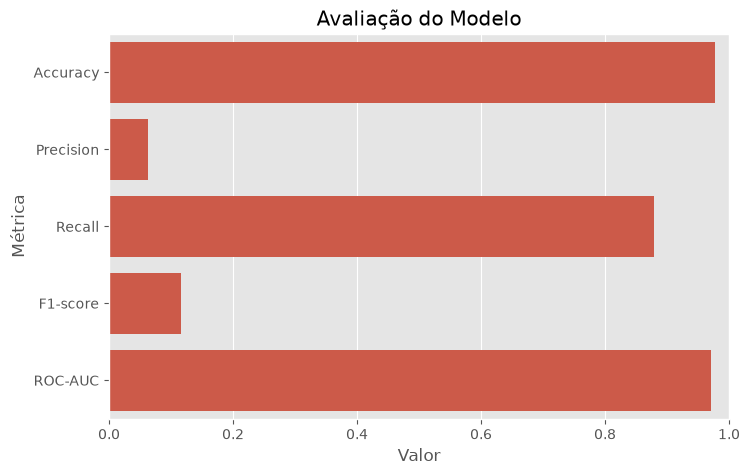

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=metricas,
    x="Valor",
    y="Métrica"
)

plt.xlim(0,1)

plt.title("Avaliação do Modelo")

plt.show()

# Avaliação do Modelo

O modelo apresentou bom desempenho geral.

Entretanto, devido ao forte desbalanceamento do conjunto de dados, a acurácia não deve ser utilizada como principal métrica de avaliação.

As métricas de Recall, Precision, F1-score e ROC-AUC fornecem uma visão mais adequada da capacidade do modelo em identificar transações fraudulentas.

Na próxima etapa serão avaliados modelos mais robustos, como Random Forest e XGBoost.

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=100,

    max_depth=10,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

rf.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [42]:
y_pred_rf = rf.predict(X_test)

y_probs_rf = rf.predict_proba(X_test)[:,1]

In [43]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.75      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.88      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [44]:
metricas_rf = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Valor":[
        accuracy_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_rf),
        roc_auc_score(y_test,y_probs_rf)
    ]

})

metricas_rf

,Métrica,Valor
0,Accuracy,0.9992
1,Precision,0.7516
2,Recall,0.7973
3,F1-score,0.7738
4,ROC-AUC,0.9799


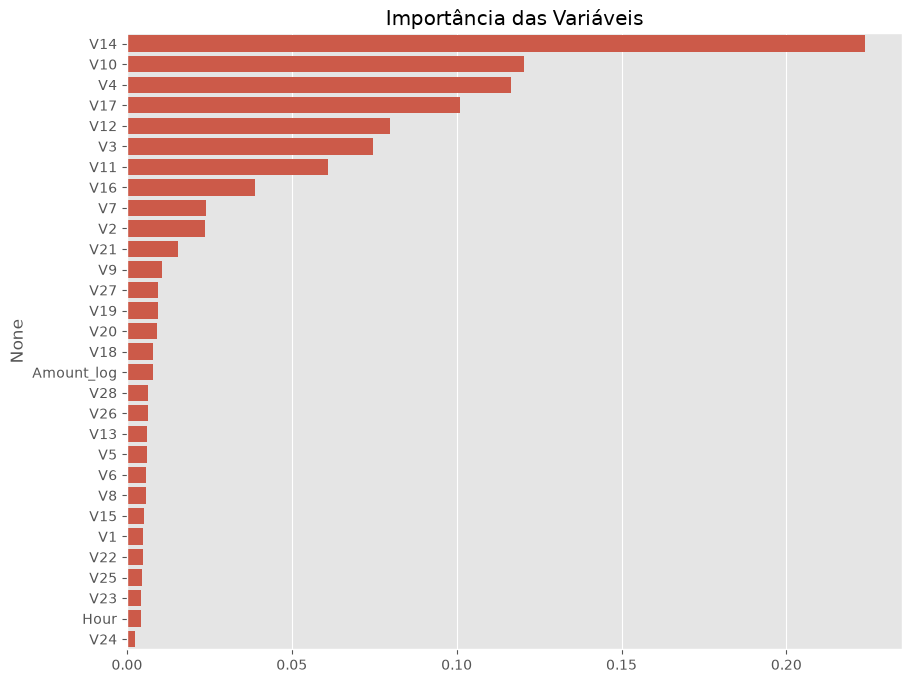

In [45]:
importancias = pd.Series(

    rf.feature_importances_,

    index=X_train.columns

)


importancias = importancias.sort_values(
    ascending=False
)


plt.figure(figsize=(10,8))

sns.barplot(

    x=importancias.values,

    y=importancias.index

)

plt.title("Importância das Variáveis")

plt.show()

In [46]:
comparacao = pd.DataFrame({

"Modelo":[

"Logistic Regression",

"Random Forest"

],

"Accuracy":[

accuracy_score(y_test,y_pred),

accuracy_score(y_test,y_pred_rf)

],

"Precision":[

precision_score(y_test,y_pred),

precision_score(y_test,y_pred_rf)

],

"Recall":[

recall_score(y_test,y_pred),

recall_score(y_test,y_pred_rf)

],

"F1":[

f1_score(y_test,y_pred),

f1_score(y_test,y_pred_rf)

],

"ROC-AUC":[

roc_auc_score(y_test,y_probs),

roc_auc_score(y_test,y_probs_rf)

]

})

comparacao

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9770,0.0625,0.8784,0.1167,0.9702
1,Random Forest,0.9992,0.7516,0.7973,0.7738,0.9799


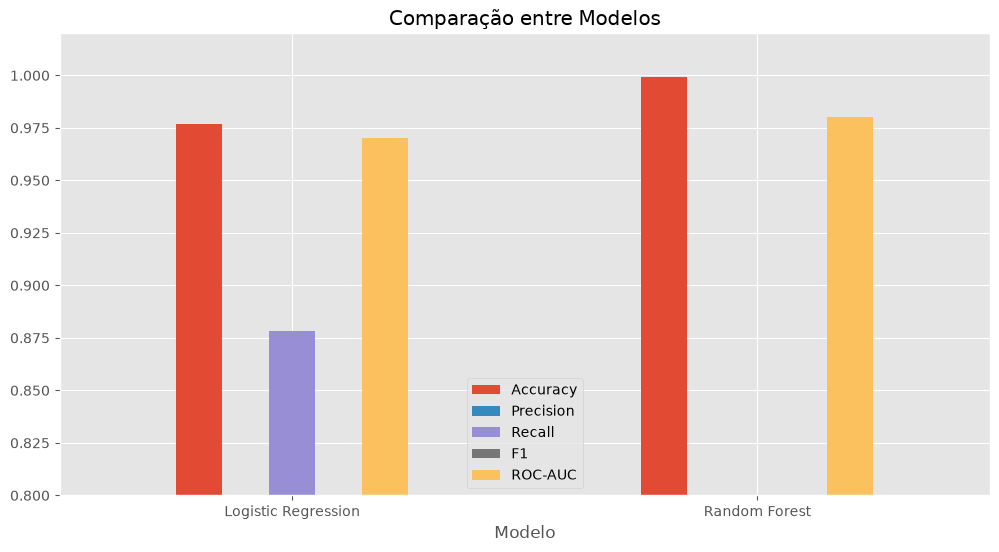

In [47]:
comparacao.set_index(
    "Modelo"
).plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("Comparação entre Modelos")

plt.xticks(rotation=0)

plt.ylim(0.8,1.02)

plt.show()

# Comparação entre Modelos

O modelo Random Forest apresentou desempenho superior à Regressão Logística em praticamente todas as métricas analisadas.

Além disso, permitiu identificar a importância relativa das variáveis utilizadas na classificação.

Na próxima etapa será avaliado um modelo baseado em Gradient Boosting (XGBoost), amplamente utilizado em competições de Machine Learning e aplicações reais de detecção de fraude.